In [34]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc

In [32]:
case = '00000'
readcase = '00100'
readpath = os.getcwd() + os.sep + 'data' + os.sep + readcase + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

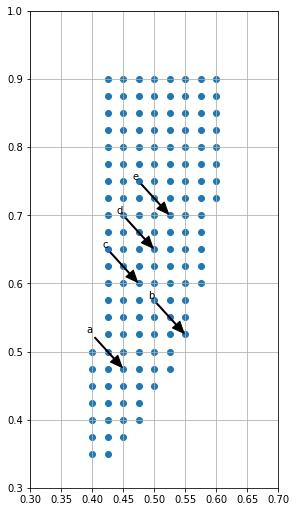

In [18]:
#ind = [21, 49, 77, 105, 126]
ind = [20, 35, 50, 65, 80]
str_ind = ['a', 'b', 'c', 'd', 'e']

fig1, ax = plt.subplots(constrained_layout=True, figsize = (4,7) )
ax.scatter(ext_exc, ext_inh)
ax.set_xlim(0.3, 0.7)
ax.set_ylim(0.3, 1.)

for i in range(len(ind)):
    x_ = ext_exc[ind[i]]
    y_ = ext_inh[ind[i]]
    ax.annotate(str_ind[i], xy=(x_, y_),  xycoords='data',
            xytext=(x_ - 0.05, y_ + 0.05), textcoords='data',
            arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
            horizontalalignment='right', verticalalignment='bottom',
            )
    
plt.savefig( os.path.join(os.getcwd(), 'examples') )

In [21]:
data.set_parameters(aln)
case = '00000'
casepath = '00100'
readpath = '.' + os.sep + 'data' + os.sep + case
control_data = data.read_control(readpath, case)

grid_resolution = layout.grid_resolution

amp_range = np.arange(6, 10, 1.)
start_range = np.arange(0., 40, 5)
#dur_range = np.arange(0, 50, 10)

weights = [1., 0., 1.]
mincost = np.zeros(len(ind))
mincost[:] = 1000.
minind = np.zeros(( len(ind), 3 ))
optcost = np.zeros(len(ind))
dist_ = np.zeros(len(ind))
DC_control = [None] * len(ind)

trans_time = 0.8

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])
    
    dist_[i] = data.dist_right(ext_exc[ind[i]], ext_inh[ind[i]], ext_exc, ext_inh, grid_resolution)
    
    opt_cntrl = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node = control_data[4][ind[i]]
    optcost[i] = opt_cost_node[0][0][0] + opt_cost_node[2][0][0]

    for a in amp_range:
        print(a)
        for start in start_range:
            for dur in np.arange(0, 80 - start, 5):
                cost_DC, control_DC = data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], start, dur,
                                        [a * dist_[i],0], 100., case, trans_time, weights,
                                         opt_cntrl, opt_cost_node, weights)
                total_cost = ( weights[0] * cost_DC[0][0][0] + weights[1] * sum(cost_DC[1][0][:])
                              + weights[2] * sum(cost_DC[2][0][:]) )
                if total_cost < mincost[i]:
                    minind[i] = [a, start, dur]
                    mincost[i] = total_cost
                    DC_control[i] = control_DC.copy()

    print('minimal cost = ', mincost[i], ' for indices = ', minind[i])

0.4500000000000001 0.4750000000000002
6.0
7.0
8.0
9.0
minimal cost =  4.314760887138942  for indices =  [ 9.  0. 30.]
0.5500000000000003 0.5250000000000002
6.0
7.0
8.0
9.0
minimal cost =  0.7560358143121925  for indices =  [ 9.  0. 45.]
0.47500000000000014 0.6000000000000003
6.0
7.0
8.0
9.0
minimal cost =  5.6922171816315705  for indices =  [ 8.  0. 40.]
0.5000000000000002 0.6500000000000004
6.0
7.0
8.0
9.0
minimal cost =  4.982608432774438  for indices =  [ 9.  0. 40.]
0.5250000000000001 0.7000000000000004
6.0
7.0
8.0
9.0
minimal cost =  4.395372165990541  for indices =  [ 9.  0. 60.]


0.4500000000000001 0.4750000000000002
EXAMPLE  1
DC minimal cost =  4.314760887138942  for indices =  [ 9.  0. 30.]
Optimal cost =  3.991259751810626
DC higher by   8.105238832966455


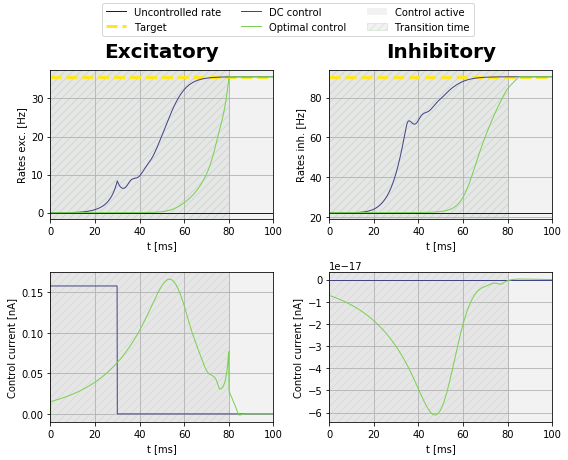

0.5500000000000003 0.5250000000000002
EXAMPLE  2
DC minimal cost =  0.7560358143121925  for indices =  [ 9.  0. 45.]
Optimal cost =  0.6638377764118296
DC higher by   13.888639841907002


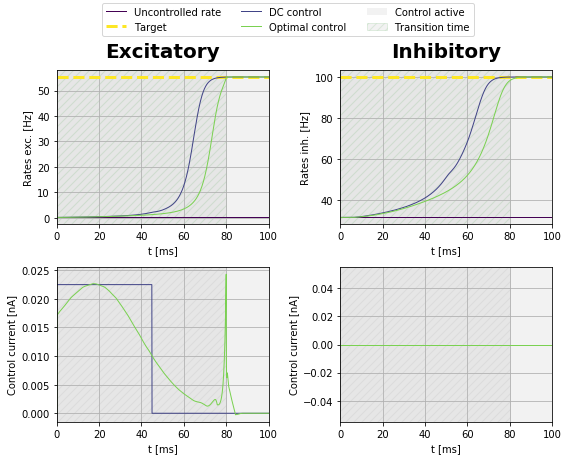

0.47500000000000014 0.6000000000000003
EXAMPLE  3
DC minimal cost =  5.6922171816315705  for indices =  [ 8.  0. 40.]
Optimal cost =  5.385847006963849
DC higher by   5.68843070127294


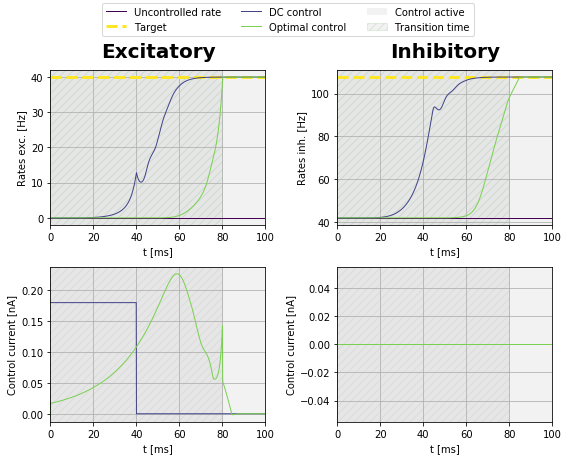

0.5000000000000002 0.6500000000000004
EXAMPLE  4
DC minimal cost =  4.982608432774438  for indices =  [ 9.  0. 40.]
Optimal cost =  4.621792835984905
DC higher by   7.806831885242715


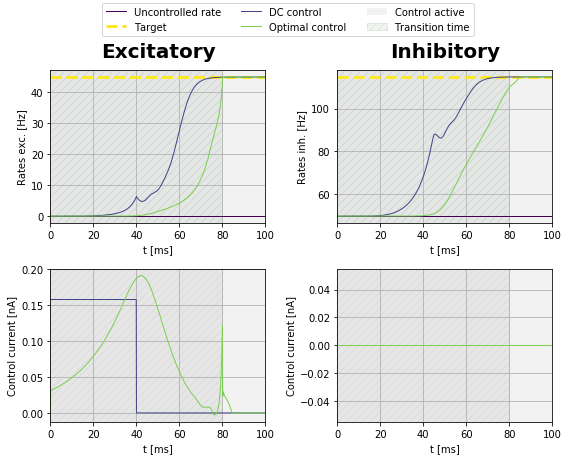

0.5250000000000001 0.7000000000000004
EXAMPLE  5
DC minimal cost =  4.395372165990541  for indices =  [ 9.  0. 60.]
Optimal cost =  4.037643193668498
DC higher by   8.85984608256134


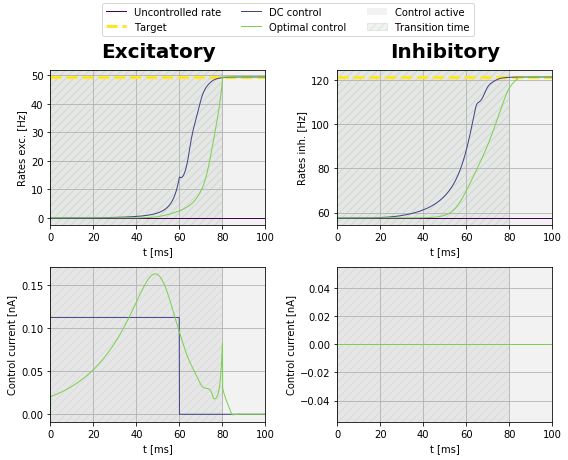

optimal control on average better by  8.86979746879009


In [22]:
av_perc = 0.

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])    
    opt_cntrl = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node = control_data[4][ind[i]]

    print("EXAMPLE ", i+1 )
    print('DC minimal cost = ', mincost[i], ' for indices = ', minind[i])
    print('Optimal cost = ', optcost[i])
    print('DC higher by  ', 100*( mincost[i]/optcost[i] - 1) )
    av_perc += 100 * ( mincost[i]/optcost[i] - 1)
    data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], minind[i][1], minind[i][2], [minind[i][0] * dist_[i],0],
                100., case, trans_time, weights, opt_cntrl, opt_cost_node, weights, plot_=True)
    plt.show()
    
print('optimal control on average better by ', av_perc/len(ind))

In [23]:
data.set_parameters(aln)
case = '00001'
casepath = '00101'
readpath = '.' + os.sep + 'data' + os.sep + casepath + os.sep
control_data = data.read_control(readpath, case)

grid_resolution = layout.grid_resolution

amp_range = np.arange(6, 10, 1.)
start_range = np.arange(0., 20, 1)

weights = [1., 0., 1.]
mincost_400 = np.zeros(len(ind))
mincost_400[:] = 1000.
minind_400 = np.zeros(( len(ind), 3 ))
optcost_400 = np.zeros(len(ind))
DC_control_400 = [None] * len(ind)

trans_time = 0.8

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])
    
    dist_[i] = data.dist_right(ext_exc[ind[i]], ext_inh[ind[i]], ext_exc, ext_inh, grid_resolution)
    
    opt_cntrl_400 = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node_400 = control_data[4][ind[i]]
    optcost_400[i] = opt_cost_node_400[0][0][0] + opt_cost_node_400[2][0][0]

    for a in amp_range:
        print(a)
        for start in start_range:
            for dur in np.arange(20, 80, 5):
                cost_DC, control_DC = data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], start, dur,
                                        [a * dist_[i],0], 400., case, trans_time, weights,
                                         opt_cntrl_400, opt_cost_node_400, weights)
                total_cost = ( weights[0] * cost_DC[0][0][0] + weights[1] * sum(cost_DC[1][0][:])
                              + weights[2] * sum(cost_DC[2][0][:]) )
                if total_cost < mincost_400[i]:
                    minind_400[i] = [a, start, dur]
                    mincost_400[i] = total_cost
                    DC_control_400[i] = control_DC.copy()

    print('minimal cost = ', mincost_400[i], ' for indices = ', minind_400[i], DC_control_400[i][0,0,::300])

0.4500000000000001 0.4750000000000002
6.0
7.0
8.0
9.0
minimal cost =  4.1087749086558505  for indices =  [ 7.  0. 45.] [0.6125 0.6125 0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.    ]
0.5500000000000003 0.5250000000000002
6.0
7.0
8.0
9.0
minimal cost =  0.5303300858899098  for indices =  [ 6.  0. 50.] [0.075 0.075 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.   ]
0.47500000000000014 0.6000000000000003
6.0
7.0
8.0
9.0
minimal cost =  5.568465901844087  for indices =  [ 7.  0. 50.] [0.7875 0.7875 0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.    ]
0.5000000000000002 0.6500000000000004
6.0
7.0
8.0
9.0
minimal cost =  4.938132870832872  for indices =  [ 7.  0. 65.] [0.6125 0.6125 0.6125 0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.    ]
0.5250000000000001 0.7000000000000004
6.0
7.0
8.0
9.0
minimal cost =  4.171611648991303  for indices =  [ 9.  0. 55.] [0.5625 0.5625 0.     0.     0. 

0.4500000000000001 0.4750000000000002
EXAMPLE  1
DC minimal cost =  4.1087749086558505  for indices =  [ 7.  0. 45.]
Optimal cost =  3.7913052314348863
DC higher by   8.373624855860328


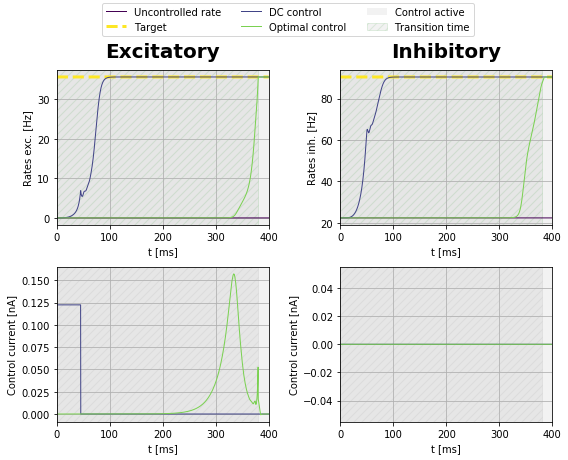

0.5500000000000003 0.5250000000000002
EXAMPLE  2
DC minimal cost =  0.5303300858899098  for indices =  [ 6.  0. 50.]
Optimal cost =  0.4159836713923071
DC higher by   27.48819782153531


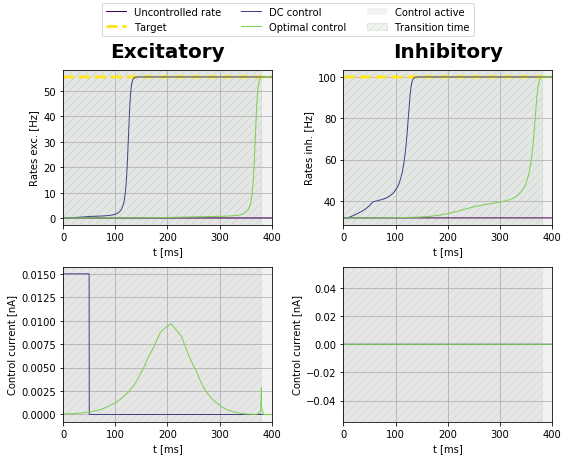

0.47500000000000014 0.6000000000000003
EXAMPLE  3
DC minimal cost =  5.568465901844087  for indices =  [ 7.  0. 50.]
Optimal cost =  5.00880866339198
DC higher by   11.173460119219358


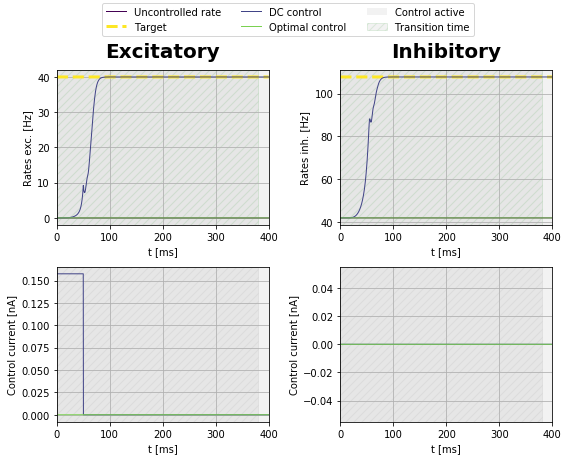

0.5000000000000002 0.6500000000000004
EXAMPLE  4
DC minimal cost =  4.938132870832872  for indices =  [ 7.  0. 65.]
Optimal cost =  4.46846536240964
DC higher by   10.510711627626023


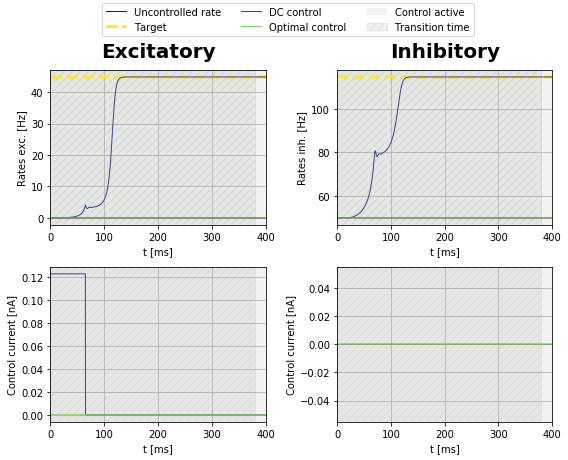

0.5250000000000001 0.7000000000000004
EXAMPLE  5
DC minimal cost =  4.171611648991303  for indices =  [ 9.  0. 55.]
Optimal cost =  3.7850974758433487
DC higher by   10.21147211174096


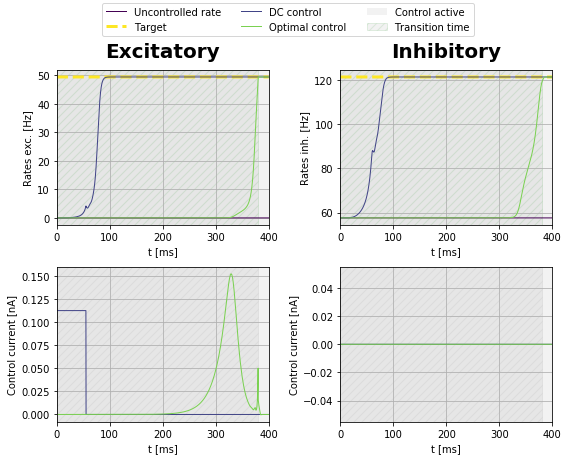

optimal control on average better by  13.551493307196395


In [24]:
av_perc = 0.
trans_time = 0.95

data.set_parameters(aln)
case = '00001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])    
    opt_cntrl = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node = control_data[4][ind[i]]

    print("EXAMPLE ", i+1 )
    print('DC minimal cost = ', mincost_400[i], ' for indices = ', minind_400[i])
    print('Optimal cost = ', optcost_400[i])
    print('DC higher by  ', 100*( mincost_400[i]/optcost_400[i] - 1) )
    av_perc += 100 * ( mincost_400[i]/optcost_400[i] - 1)
    data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], minind_400[i][1], minind_400[i][2],
                  [minind_400[i][0] * dist_[i],0],
                400., case, trans_time, weights, opt_cntrl, opt_cost_node, weights, plot_=True, max_it = 0 )
    plt.show()
    
    
print('optimal control on average better by ', av_perc/len(ind))

In [35]:
opt_cntrl_100_b = [None] * len(ind)
cost_node_100_b = [None] * len(ind)

opt_cntrl_400_b = [None] * len(ind)
cost_node_400_b = [None] * len(ind)

opt_cntrl_400_0 = [None] * len(ind)
cost_node_400_0 = [None] * len(ind)

opt_cntrl_400_1 = [None] * len(ind)
cost_node_400_1 = [None] * len(ind)

opt_cntrl_400_2 = [None] * len(ind)
cost_node_400_2 = [None] * len(ind)

opt_cntrl_400_3 = [None] * len(ind)
cost_node_400_3 = [None] * len(ind)

opt_cntrl_400_4 = [None] * len(ind)
cost_node_400_4 = [None] * len(ind)

opt_cntrl_400_5 = [None] * len(ind)
cost_node_400_5 = [None] * len(ind)

target_100 = [None] * len(ind)
target_400 = [None] * len(ind)

initVars = [None] * len(ind)

case = '00000'
casepath = '00100'
readpath = '.' + os.sep + 'data' + os.sep + casepath + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_100_b[i] = control_data[2][ind[i]]
    cost_node_100_b[i] = control_data[4][ind[i]]

case = '00001'
casepath = '00101'
readpath = '.' + os.sep + 'data' + os.sep + casepath + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_b[i] = control_data[2][ind[i]]
    cost_node_400_b[i] = control_data[4][ind[i]]


case = '00031'
casepath = '00131'
readpath = '.' + os.sep + 'data' + os.sep + casepath + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_0[i] = control_data[2][ind[i]]
    cost_node_400_0[i] = control_data[4][ind[i]]

    
case = '00031'
readpath = '.' + os.sep + 'data' + os.sep + 'shift_init' + os.sep + '1' + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_1[i] = control_data[2][ind[i]]
    cost_node_400_1[i] = control_data[4][ind[i]]
readpath = '.' + os.sep + 'data' + os.sep + 'shift_init' + os.sep + '2' + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_2[i] = control_data[2][ind[i]]
    cost_node_400_2[i] = control_data[4][ind[i]]
readpath = '.' + os.sep + 'data' + os.sep + 'shift_init' + os.sep + '3' + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_3[i] = control_data[2][ind[i]]
    cost_node_400_3[i] = control_data[4][ind[i]]
readpath = '.' + os.sep + 'data' + os.sep + 'shift_init' + os.sep + '4' + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_4[i] = control_data[2][ind[i]]
    cost_node_400_4[i] = control_data[4][ind[i]]
readpath = '.' + os.sep + 'data' + os.sep + 'shift_init' + os.sep + '5' + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_5[i] = control_data[2][ind[i]]
    cost_node_400_5[i] = control_data[4][ind[i]]
    
case = '00000'
casepath = '00100'
readpath = '.' + os.sep + 'data' + os.sep + casepath + os.sep

data.set_parameters(aln)

for i in range(len(ind)):
    
    print("------- ", i, ext_exc[ind[i]], ext_inh[ind[i]])
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100[i] = aln.getZeroTarget()
    target_100[i][:,0,:] = target_rates[0]
    target_100[i][:,1,:] = target_rates[1]
    
    aln.params.duration = 400.

    target_400[i] = aln.getZeroTarget()
    target_400[i][:,0,:] = target_rates[0]
    target_400[i][:,1,:] = target_rates[1]

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002
-------  2 0.47500000000000014 0.6000000000000003
-------  3 0.5000000000000002 0.6500000000000004
-------  4 0.5250000000000001 0.7000000000000004


0 0.4500000000000001 0.4750000000000002


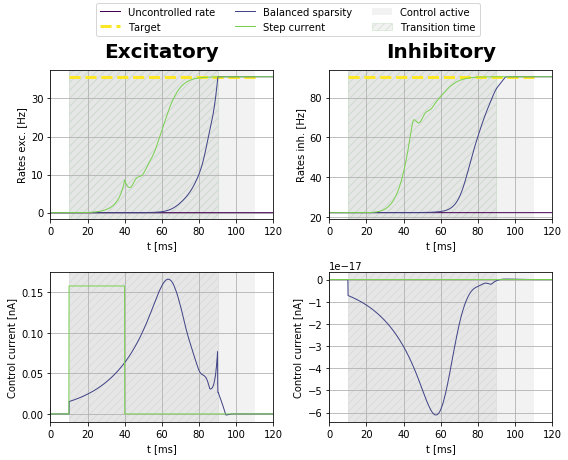

1 0.5500000000000003 0.5250000000000002


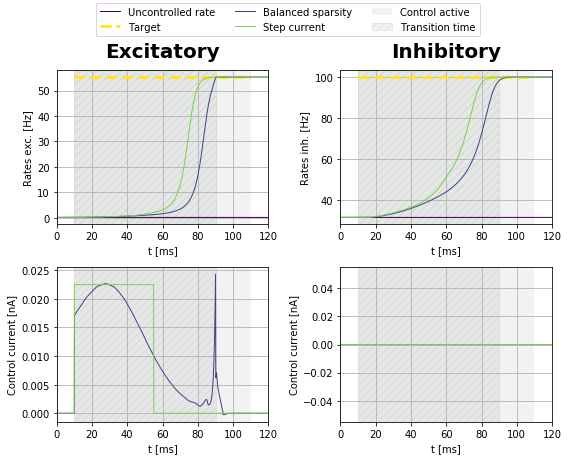

2 0.47500000000000014 0.6000000000000003


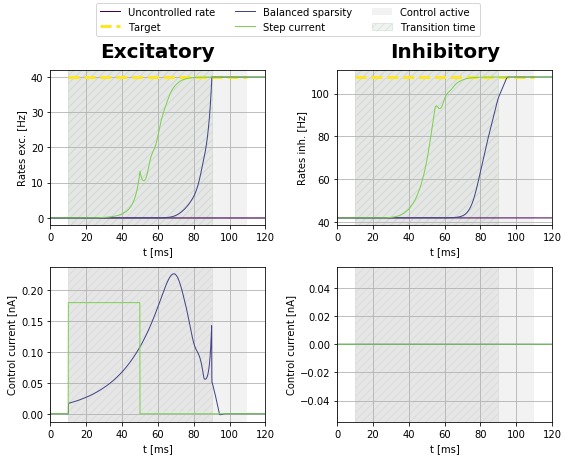

3 0.5000000000000002 0.6500000000000004


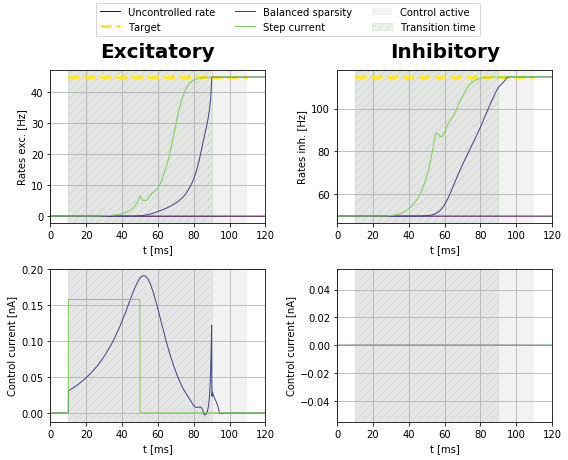

4 0.5250000000000001 0.7000000000000004


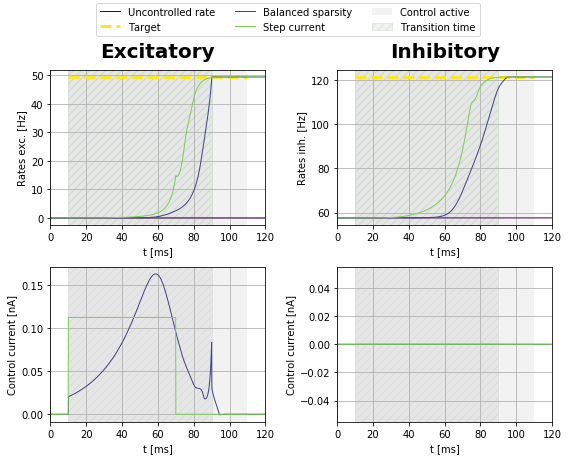

In [46]:
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

DC_control_shapeadjust = [None] * len(ind)

for i in range(len(ind)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
    
    print(ind[i], ext_exc[ind[i]], ext_inh[ind[i]])
        
    DC_control_shapeadjust[i] = np.zeros(( opt_cntrl_100_b[i].shape ))
    DC_control_shapeadjust[i][:,:,100:-100] = DC_control[i].copy()
    DC_control_shapeadjust[i][:,:,-100:] = 0.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_100_b[i], DC_control_shapeadjust[i]],
                                  [cost_node_100_b[i], cost_node_100_b[i]],
                         [weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                         target_100[i], path_=os.getcwd(), filename_ = str(i) + '_100', shading = False, transition_time_ = 0.8,
                         labels_ = ['Balanced sparsity', 'Step current'],
                         precision_variables_ = [0], print_cost_ = False)
    plt.show()

20 0.4500000000000001 0.4750000000000002
cost b =  3.799
cost 0 =  3.741
cost 1 =  3.734
cost 2 =  3.734
cost 3 =  3.734
cost 4 =  3.734
cost 5 =  3.734


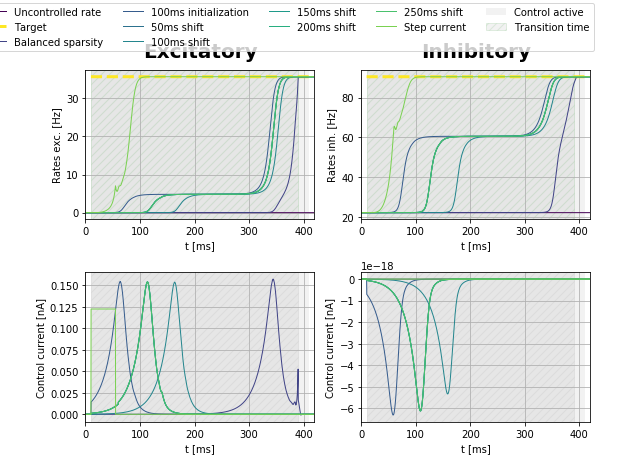

35 0.5500000000000003 0.5250000000000002
cost b =  0.416
cost 0 =  0.414
cost 1 =  0.414
cost 2 =  0.412
cost 3 =  0.414
cost 4 =  0.416
cost 5 =  0.416


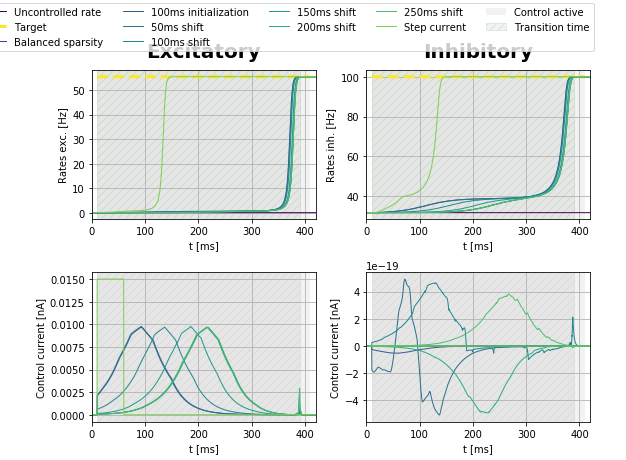

50 0.47500000000000014 0.6000000000000003
cost b =  15942.955
cost 0 =  5.02
cost 1 =  5.006
cost 2 =  5.021
cost 3 =  5.007
cost 4 =  5.007
cost 5 =  5.014


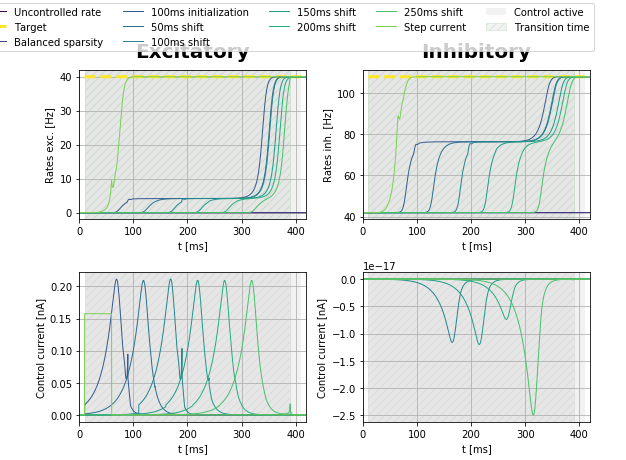

65 0.5000000000000002 0.6500000000000004
cost b =  20071.115
cost 0 =  4.509
cost 1 =  4.461
cost 2 =  4.461
cost 3 =  4.461
cost 4 =  4.461
cost 5 =  4.463


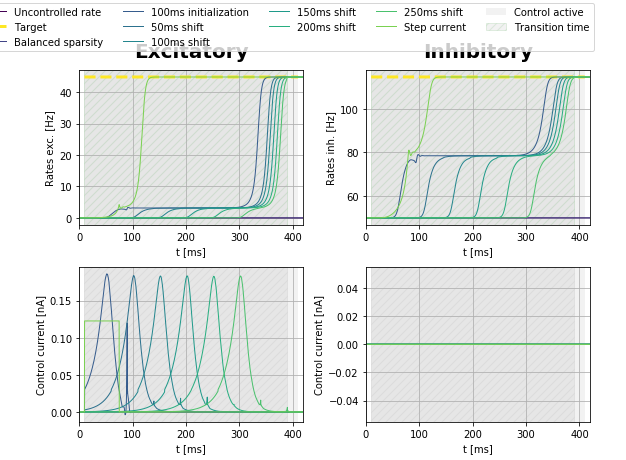

80 0.5250000000000001 0.7000000000000004
cost b =  3.836
cost 0 =  3.8
cost 1 =  3.783
cost 2 =  3.783
cost 3 =  3.784
cost 4 =  3.783
cost 5 =  3.788


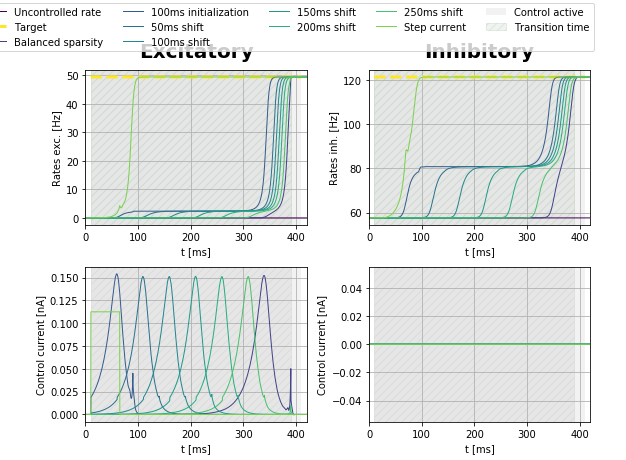

In [51]:
# 400 ms with shift

aln.params.duration = 400.
t_sim = aln.params.duration
data.set_parameters(aln)

DC_control_shapeadjust_400 = [None] * len(ind)

for i in range(len(ind)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
    
    DC_control_shapeadjust_400[i] = np.zeros(( opt_cntrl_400_b[i].shape ))
    DC_control_shapeadjust_400[i][:,:,100:-100] = DC_control_400[i].copy()
    
    print(ind[i], ext_exc[ind[i]], ext_inh[ind[i]])
    
    cost_caseb = cost_node_400_b[i][0][0][0] + sum(cost_node_400_b[i][2][0][:])
    cost_case0 = cost_node_400_0[i][0][0][0] + sum(cost_node_400_0[i][2][0][:])
    cost_case1 = cost_node_400_1[i][0][0][0] + sum(cost_node_400_1[i][2][0][:])
    cost_case2 = cost_node_400_2[i][0][0][0] + sum(cost_node_400_2[i][2][0][:])
    cost_case3 = cost_node_400_3[i][0][0][0] + sum(cost_node_400_3[i][2][0][:])
    cost_case4 = cost_node_400_4[i][0][0][0] + sum(cost_node_400_4[i][2][0][:])
    cost_case5 = cost_node_400_5[i][0][0][0] + sum(cost_node_400_5[i][2][0][:])
        
    print('cost b = ', np.round(cost_caseb, 3))
    print('cost 0 = ', np.round(cost_case0, 3))
    print('cost 1 = ', np.round(cost_case1, 3))
    print('cost 2 = ', np.round(cost_case2, 3))
    print('cost 3 = ', np.round(cost_case3, 3))
    print('cost 4 = ', np.round(cost_case4, 3))
    print('cost 5 = ', np.round(cost_case5, 3))
        
    plotFunc.plot_control_current(aln, [opt_cntrl_400_b[i], opt_cntrl_400_0[i], opt_cntrl_400_1[i],
                                        opt_cntrl_400_2[i], opt_cntrl_400_3[i], opt_cntrl_400_4[i], 
                                        opt_cntrl_400_5[i], 
                                        DC_control_shapeadjust_400[i]],
            [cost_node_400_b[i], cost_node_400_b[i], cost_node_400_b[i], cost_node_400_b[i],
            cost_node_400_b[i], cost_node_400_b[i], cost_node_400_b[i], cost_node_400_b[i]],
            [weights, weights, weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post,
            initVars[i], target_400[i], path_=os.getcwd(), filename_ = str(i) + '_400', shading = False,
                        transition_time_ = 0.95, labels_ = ['Balanced sparsity', '100ms initialization',
                                                            '50ms shift', '100ms shift', '150ms shift', 
                                                            '200ms shift', '250ms shift', 'Step current'],
                        precision_variables_ = [0], print_cost_ = False)
    plt.show()

## A and C for four settings, low => high

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


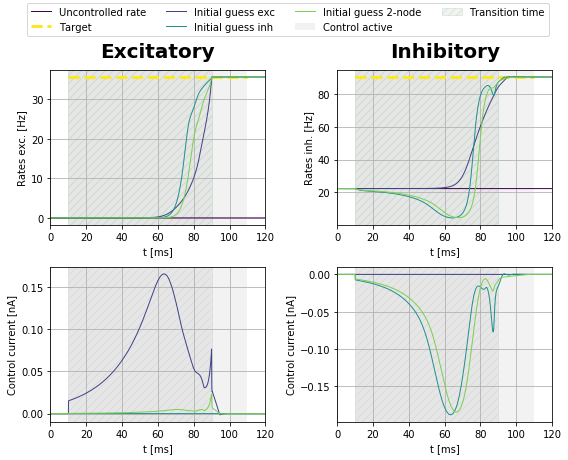

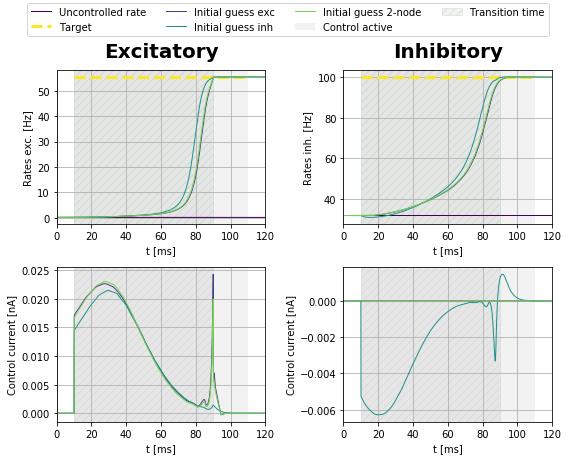

In [55]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '00000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '00010'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '00020'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '00000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_000x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


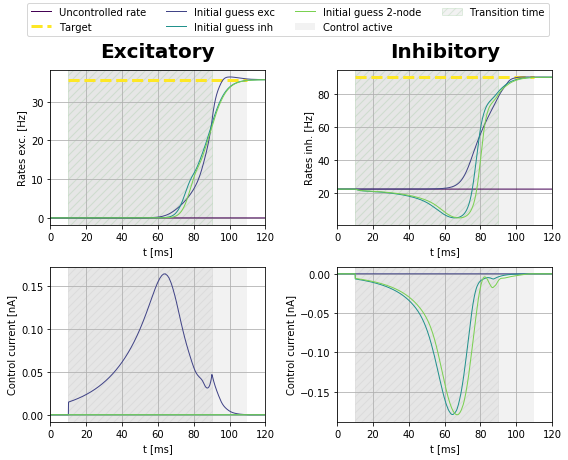

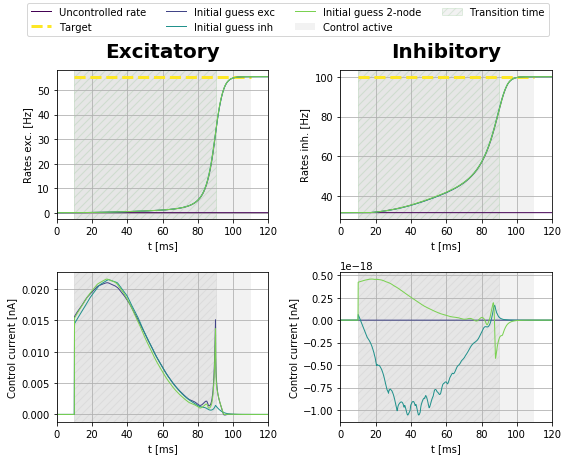

In [39]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '00100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '00110'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '00120'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '00100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_001x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


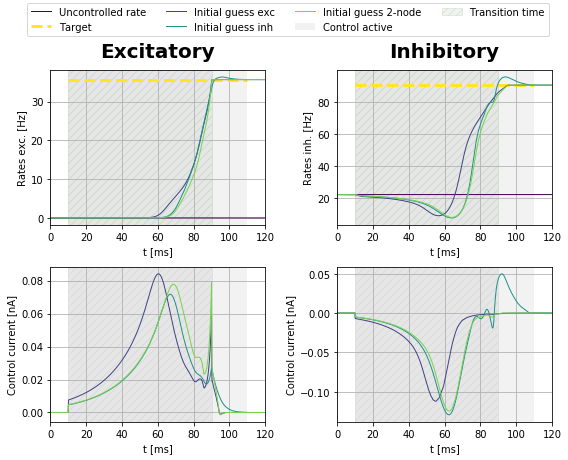

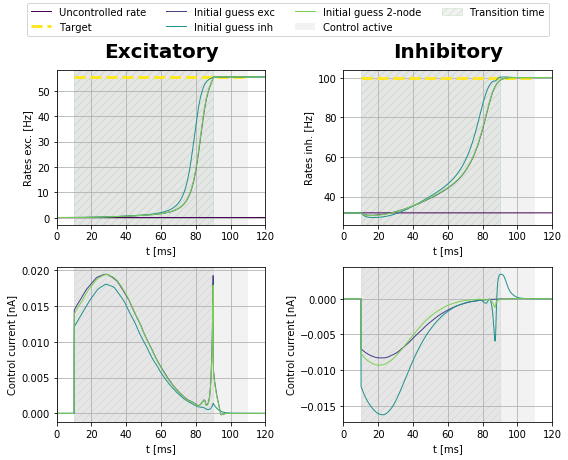

In [40]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '01000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '01010'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '01020'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '01000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_010x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


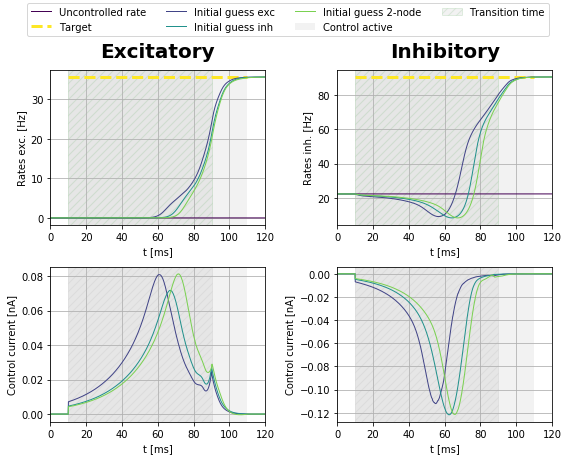

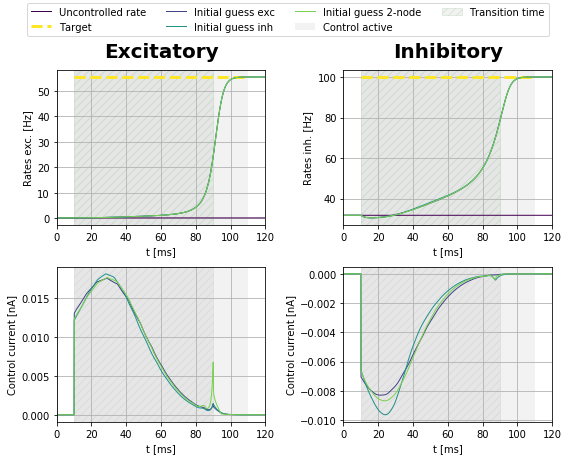

In [41]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '01100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '01110'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '01120'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '01100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_011x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


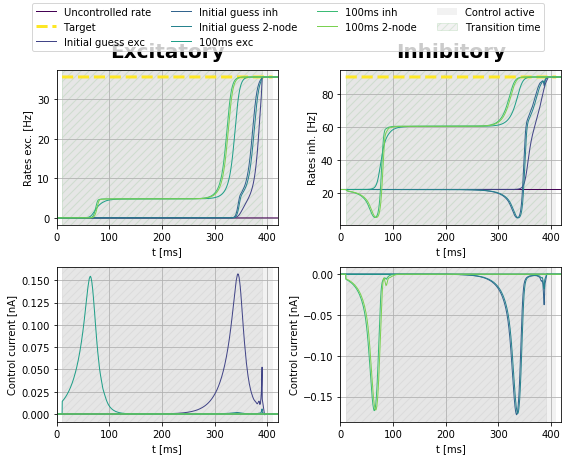

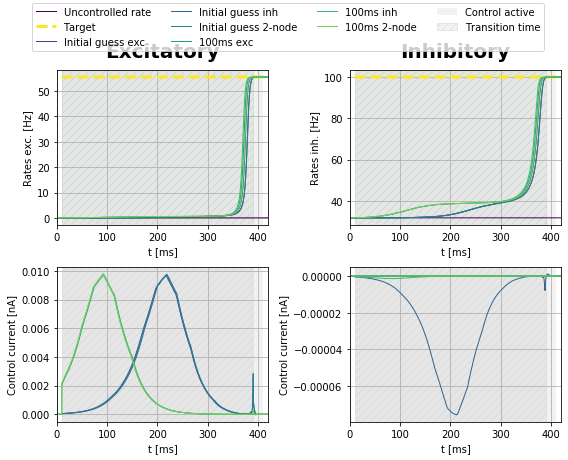

In [42]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '00001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '00011'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '00021'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '00031'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '00041'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '00051'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '00001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_000x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


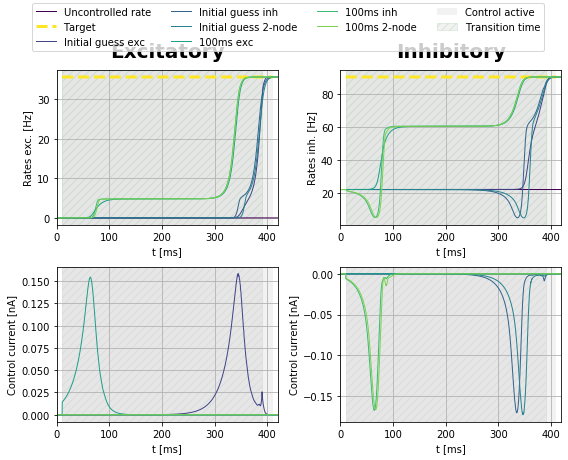

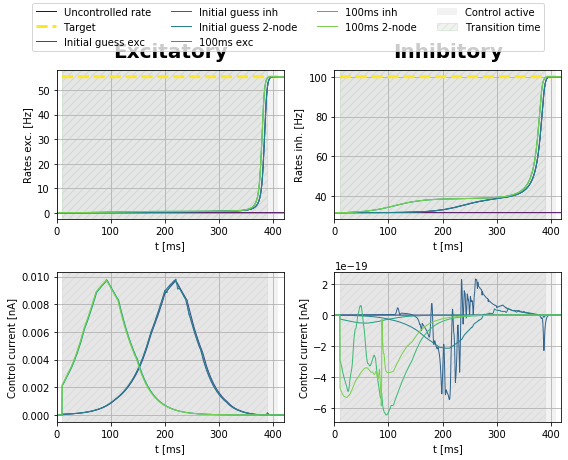

In [43]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '00101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '00111'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '00121'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '00131'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '00141'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '00151'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '00101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_001x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

In [44]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '01001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '01011'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '01021'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '01031'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '01041'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '01051'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '01001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_010x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

FileNotFoundError: [Errno 2] No such file or directory: '.\\data\\01131\\control_01031.pickle'

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


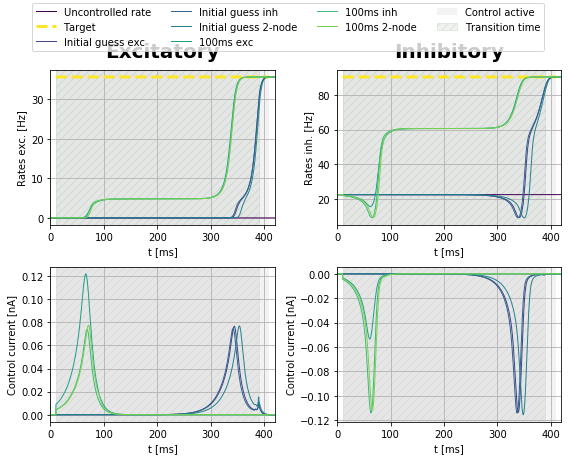

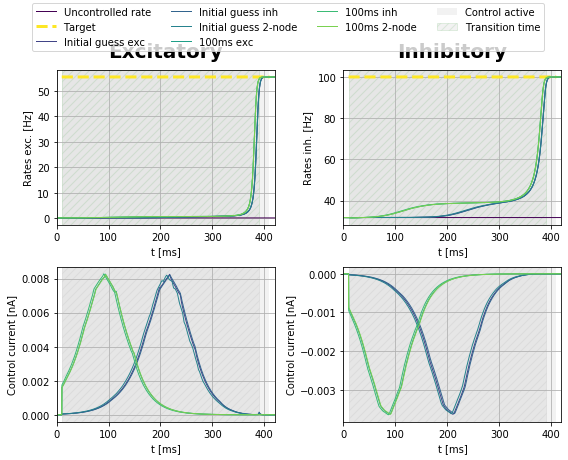

In [45]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '01101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '01111'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '01121'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '01131'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '01141'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '01151'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '01101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_011x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

## A and C for four settings, high => low

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


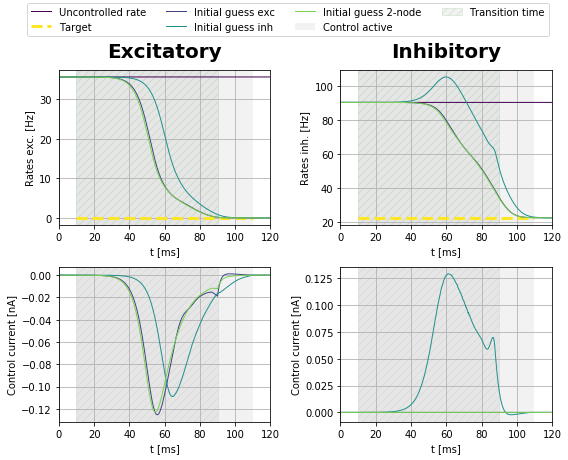

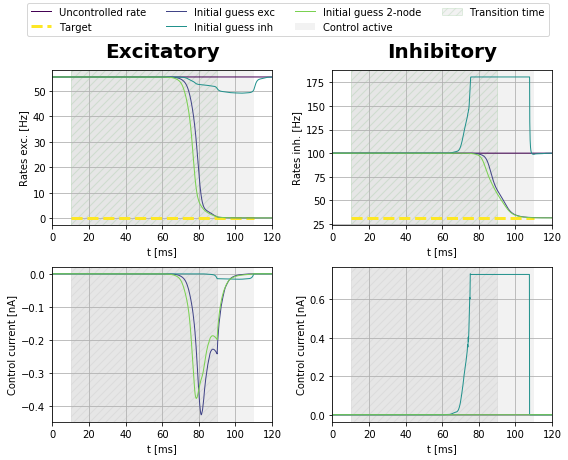

In [62]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '10000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '10010'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '10020'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '10000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_100x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


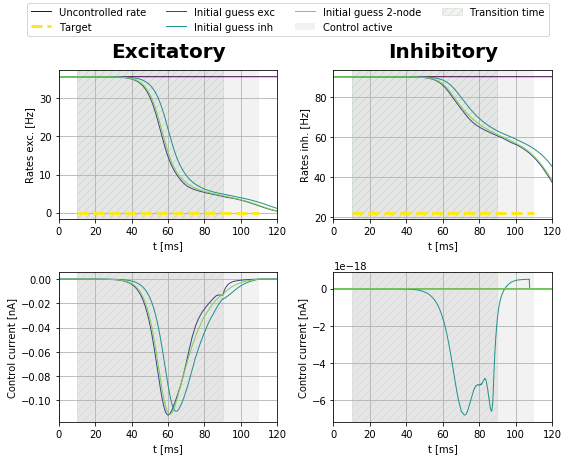

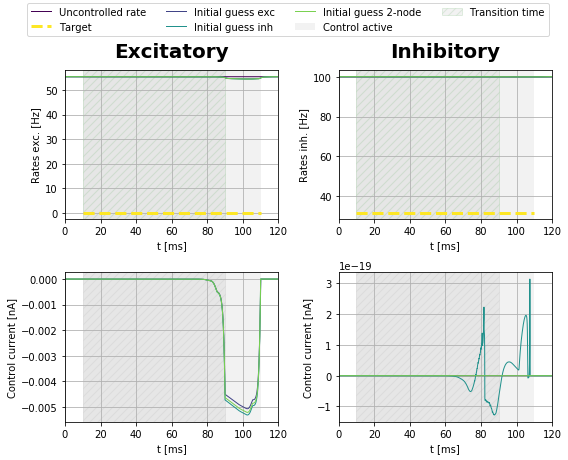

In [63]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '10100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '10110'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '10120'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '10100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_101x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


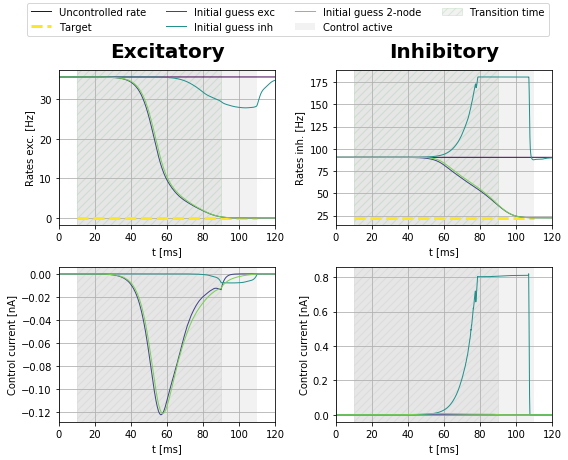

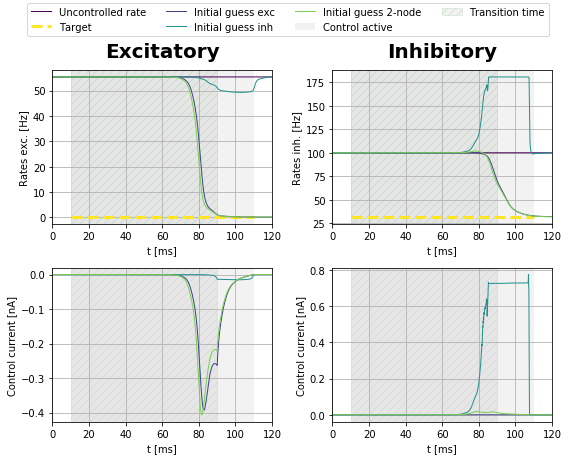

In [64]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '11000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '11010'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '11020'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '11000'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_110x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


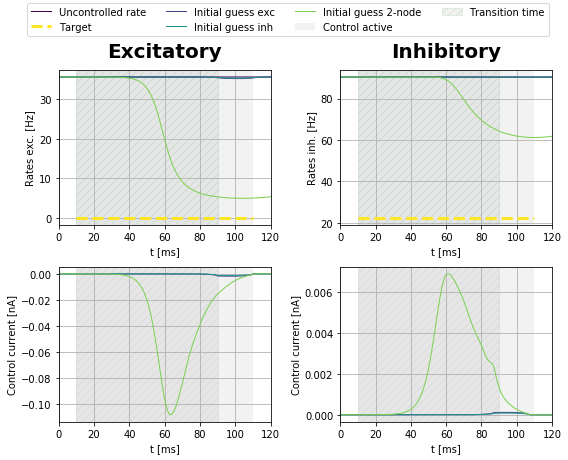

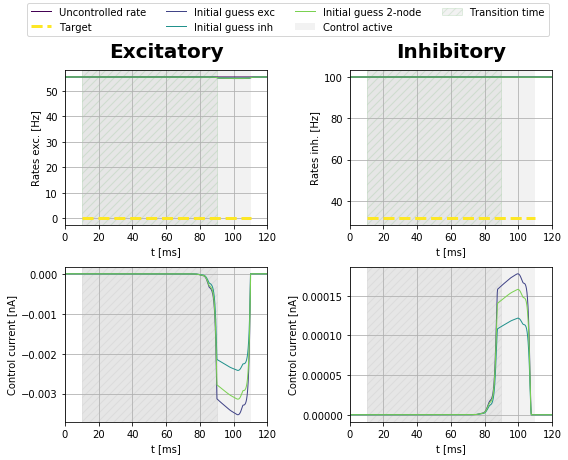

In [65]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '11100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '11110'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '11120'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '11100'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i]],
                        [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_111x0', shading = False,
                        transition_time_ = 0.8,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

In [66]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '10001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '10011'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '10021'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '10031'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '10041'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '10051'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '10001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_100x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

FileNotFoundError: [Errno 2] No such file or directory: '.\\data\\10131\\control_10031.pickle'

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.5500000000000003 0.5250000000000002


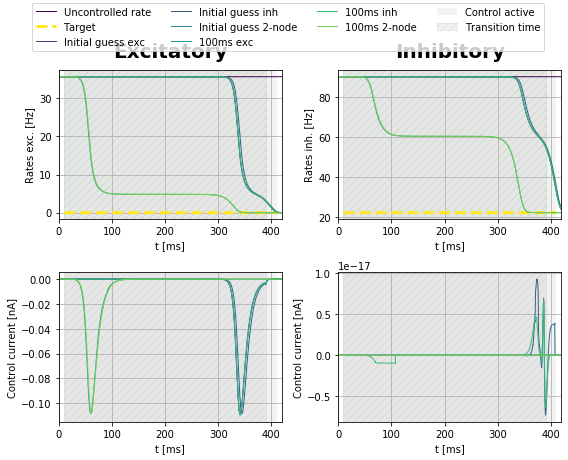

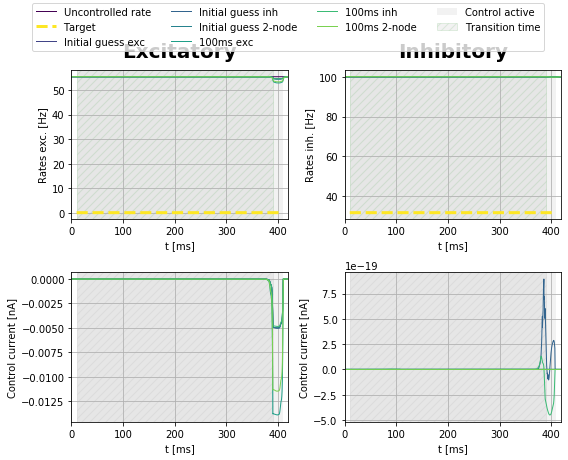

In [67]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '10101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '10111'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '10121'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '10131'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '10141'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '10151'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '10101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_101x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

In [68]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '11001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '11011'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '11021'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '11031'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '11041'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '11051'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '11001'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_110x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

EOFError: Ran out of input

In [69]:
ind_0 = ind[:2]

opt_cntrl_0 = [None] * len(ind_0)
cost_node_0 = [None] * len(ind_0)

opt_cntrl_1 = [None] * len(ind_0)
cost_node_1 = [None] * len(ind_0)

opt_cntrl_2 = [None] * len(ind_0)
cost_node_2 = [None] * len(ind_0)

opt_cntrl_3 = [None] * len(ind_0)
cost_node_3 = [None] * len(ind_0)

opt_cntrl_4 = [None] * len(ind_0)
cost_node_4 = [None] * len(ind_0)

opt_cntrl_5 = [None] * len(ind_0)
cost_node_5 = [None] * len(ind_0)

target_100_0 = [None] * len(ind_0)
initVars_0 = [None] * len(ind_0)

case = '11101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_0[i] = control_data[2][ind[i]]
    cost_node_0[i] = control_data[4][ind[i]]

case = '11111'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_1[i] = control_data[2][ind[i]]
    cost_node_1[i] = control_data[4][ind[i]]
    
case = '11121'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_2[i] = control_data[2][ind_0[i]]
    cost_node_2[i] = control_data[4][ind_0[i]]
    
case = '11131'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_3[i] = control_data[2][ind[i]]
    cost_node_3[i] = control_data[4][ind[i]]

case = '11141'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_4[i] = control_data[2][ind[i]]
    cost_node_4[i] = control_data[4][ind[i]]
    
case = '11151'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind_0)):
    opt_cntrl_5[i] = control_data[2][ind_0[i]]
    cost_node_5[i] = control_data[4][ind_0[i]]    

case = '11101'
readpath = '.' + os.sep + 'data' + os.sep + case + os.sep

data.set_parameters(aln)

for i in range(len(ind_0)):
    
    print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
    aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars_0[i] = init_state_vars
    
    aln.params.duration = 400.

    target_100_0[i] = aln.getZeroTarget()
    target_100_0[i][:,0,:] = target_rates[0]
    target_100_0[i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10

for i in range(len(ind_0)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_1[i], opt_cntrl_2[i], opt_cntrl_3[i], opt_cntrl_4[i],
                                        opt_cntrl_5[i]],
                        [cost_node_0[i], cost_node_1[i], cost_node_2[i], cost_node_3[i], cost_node_4[i], cost_node_5[i]],
                        [weights, weights, weights, weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars_0[i],
                        target_100_0[i], path_=os.getcwd(), filename_ = str(i) + '_111x1', shading = False,
                        transition_time_ = 0.95,
                        labels_ = ['Initial guess exc', 'Initial guess inh', 'Initial guess 2-node',
                                   '100ms exc', '100ms inh', '100ms 2-node'],
                        precision_variables_ = [0], print_cost_ = False)

EOFError: Ran out of input